# **Импорт библиотек и загрузка данных**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

# Настройка устройства (GPU если есть, иначе CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Преобразования данных: перевод в тензор и нормализация
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Загрузка датасета MNIST
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Создание DataLoader для итерации по батчам
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 48.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.16MB/s]


# **Визуализация**

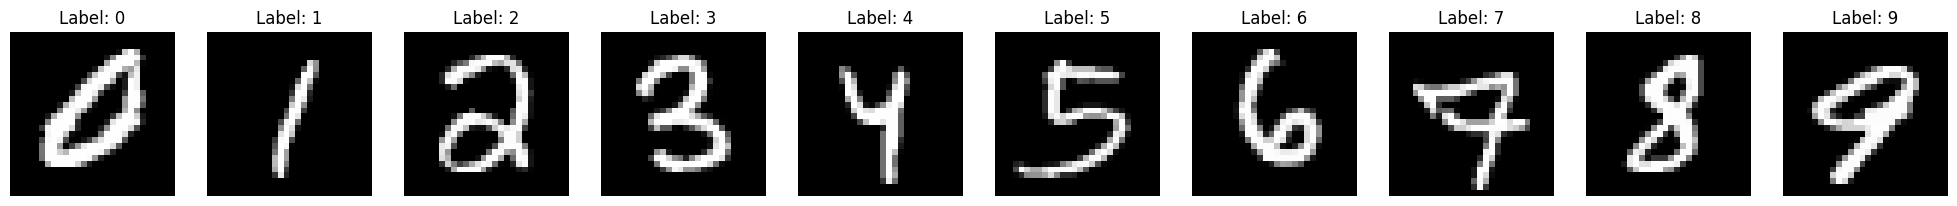

In [ ]:
# Вывод случайных изображений
fig, axs = plt.subplots(1, 10, figsize=(25, 3))
for i in range(10):
    # Находим индексы всех примеров класса i
    indices = [idx for idx, target in enumerate(train_dataset.targets) if target == i]
    index = random.choice(indices)
    img, label = train_dataset[index]

    # В PyTorch тензоры имеют размерность [C, H, W], для отрисовки убираем канал
    axs[i].imshow(img.squeeze().numpy(), cmap='gray')
    axs[i].set_title(f"Label: {label}")
    axs[i].axis('off')

plt.show()

# **Определение архитектуры нейронной сети**

In [ ]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc_layers = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10) # 10 классов на выходе
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.fc_layers(x)
        return logits

model = SimpleNet().to(device)

# **Настройка обучения**

In [ ]:
criterion = nn.CrossEntropyLoss() # Включает в себя Softmax
optimizer = optim.Adam(model.parameters(), lr=0.001)

# **Цикл обучения**

In [ ]:
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()  # Обнуляем градиенты
        output = model(data)   # Прямой проход
        loss = criterion(output, target) # Вычисление ошибки
        loss.backward()        # Обратное распространение
        optimizer.step()       # Шаг оптимизатора

        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item():.6f}')

# Запуск обучения на 5 эпох
for epoch in range(1, 6):
    train(model, device, train_loader, optimizer, criterion, epoch)

Train Epoch: 1 [0/60000] Loss: 2.319180
Train Epoch: 1 [6400/60000] Loss: 0.375053
Train Epoch: 1 [12800/60000] Loss: 0.185135
Train Epoch: 1 [19200/60000] Loss: 0.226816
Train Epoch: 1 [25600/60000] Loss: 0.229682
Train Epoch: 1 [32000/60000] Loss: 0.134192
Train Epoch: 1 [38400/60000] Loss: 0.190061
Train Epoch: 1 [44800/60000] Loss: 0.088368
Train Epoch: 1 [51200/60000] Loss: 0.161872
Train Epoch: 1 [57600/60000] Loss: 0.236866
Train Epoch: 2 [0/60000] Loss: 0.100785
Train Epoch: 2 [6400/60000] Loss: 0.306651
Train Epoch: 2 [12800/60000] Loss: 0.133527
Train Epoch: 2 [19200/60000] Loss: 0.282569
Train Epoch: 2 [25600/60000] Loss: 0.029641
Train Epoch: 2 [32000/60000] Loss: 0.095776
Train Epoch: 2 [38400/60000] Loss: 0.077620
Train Epoch: 2 [44800/60000] Loss: 0.160543
Train Epoch: 2 [51200/60000] Loss: 0.070941
Train Epoch: 2 [57600/60000] Loss: 0.162470
Train Epoch: 3 [0/60000] Loss: 0.034154
Train Epoch: 3 [6400/60000] Loss: 0.025729
Train Epoch: 3 [12800/60000] Loss: 0.011815
Tra

# **Проверка точности**

In [ ]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad(): # Отключаем расчет градиентов для экономии памяти
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({100. * correct / len(test_loader.dataset):.2f}%)\n')

test(model, device, test_loader)


Test set: Average loss: 0.0001, Accuracy: 9803/10000 (98.03%)



NameError: name 'train_acc' is not defined

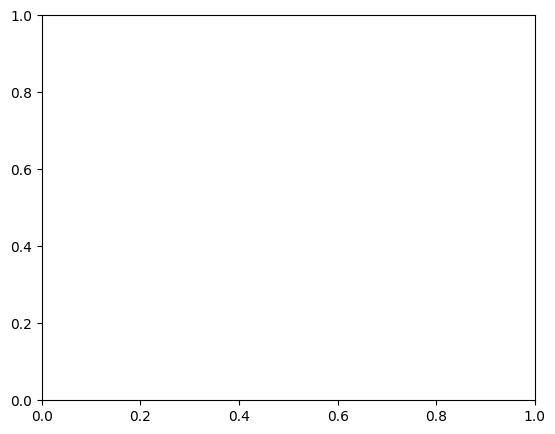

In [ ]:
import matplotlib.pyplot as plt

# Настройка размера графиков
plt.figure(figsize=(14, 5))

# 1. График точности (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(train_acc, 'b-o', label='Обучающая выборка')
plt.plot(test_acc, 'r-o', label='Тестовая выборка')
plt.title('Точность модели (Accuracy)')
plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.grid(True)

# 2. График потерь (Loss)
plt.subplot(1, 2, 2)
plt.plot(train_loss, 'b-o', label='Обучающая выборка')
plt.plot(test_loss, 'r-o', label='Тестовая выборка')
plt.title('Функция потерь (Loss)')
plt.xlabel('Эпоха обучения')
plt.ylabel('Значение ошибки')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()